# Energy Optimization and Recommendation System

## Objective

This component integrates forecasting, deep learning, peak detection,
anomaly detection, and consumption clustering outputs to identify
energy-saving opportunities and generate data-driven optimization
recommendations.

### Inputs
- Forecasting results
- LSTM/GRU prediction results
- Peak detection results
- Anomaly detection results
- Consumption clustering results

### Outputs
- Integrated optimization dataset
- Data-driven energy recommendations
- Recommendation reasons and priorities
- Recommendation validation results
- `recommendations.csv`

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

REPORTS_DIR = Path("../reports")

CLUSTERS_PATH = REPORTS_DIR / "clusters.csv"
CLUSTER_INFO_PATH = REPORTS_DIR / "cluster_info.csv"

PEAK_PATH = REPORTS_DIR / "peak_predictions_hourly.csv"
ANOMALY_PATH = REPORTS_DIR / "anomaly_scores_hourly.csv"

DL_PATH = REPORTS_DIR / "final_dl_predictions.csv"
FORECAST_PATH = REPORTS_DIR / "xgboost_test_predictions.csv"

In [4]:
clusters = pd.read_csv(CLUSTERS_PATH)
cluster_info = pd.read_csv(CLUSTER_INFO_PATH)

peak = pd.read_csv(PEAK_PATH)
anomaly = pd.read_csv(ANOMALY_PATH)

dl_predictions = pd.read_csv(DL_PATH)
forecast_predictions = pd.read_csv(FORECAST_PATH)

print("Clusters:", clusters.shape)
print("Cluster info:", cluster_info.shape)
print("Peak predictions:", peak.shape)
print("Anomaly results:", anomaly.shape)
print("DL predictions:", dl_predictions.shape)
print("Forecast predictions:", forecast_predictions.shape)

datasets = {
    "Clusters": clusters,
    "Cluster Info": cluster_info,
    "Peak Detection": peak,
    "Anomaly Detection": anomaly,
    "Deep Learning": dl_predictions,
    "Forecasting": forecast_predictions
}

for name, data in datasets.items():
    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print("Shape:", data.shape)

    print("\nColumns:")
    print(data.columns.tolist())

    print("\nFirst 3 rows:")
    display(data.head(3))
    
for name, data in datasets.items():
    print(f"\n{name}")
    print(data.dtypes)

for name, data in datasets.items():
    print(f"\n{name} - Missing Values")
    print(data.isnull().sum()[data.isnull().sum() > 0])

Clusters: (1420, 8)
Cluster info: (4, 15)
Peak predictions: (5120, 9)
Anomaly results: (5120, 19)
DL predictions: (307058, 4)
Forecast predictions: (307117, 4)

Clusters
Shape: (1420, 8)

Columns:
['Date', 'cluster', 'cluster_name', 'avg_consumption', 'peak_consumption', 'min_consumption', 'std_consumption', 'is_weekend']

First 3 rows:


,Date,cluster,cluster_name,avg_consumption,peak_consumption,min_consumption,std_consumption,is_weekend
0,2006-12-17,2,Peak-Heavy Pattern,2.354486,7.064,0.206,1.205795,1
1,2006-12-18,1,High Consumption Pattern,1.530435,6.158,0.202,1.005074,0
2,2006-12-19,2,Peak-Heavy Pattern,1.157079,7.840,0.194,1.237602,0



Cluster Info
Shape: (4, 15)

Columns:
['cluster', 'avg_consumption', 'peak_consumption', 'min_consumption', 'std_consumption', 'avg_voltage', 'avg_sub1', 'avg_sub2', 'avg_sub3', 'avg_morning', 'avg_evening', 'avg_night', 'is_weekend', 'cluster_name', 'num_days']

First 3 rows:


,cluster,avg_consumption,peak_consumption,min_consumption,std_consumption,avg_voltage,avg_sub1,avg_sub2,avg_sub3,avg_morning,avg_evening,avg_night,is_weekend,cluster_name,num_days
0,0,0.509,2.751,0.165,0.439,241.220,0.152,0.443,3.048,0.555,0.583,0.427,0.293,Low Consumption Pattern,205
1,1,1.157,5.394,0.237,0.909,241.790,0.883,0.774,7.443,1.490,1.581,0.516,0.178,High Consumption Pattern,545
2,2,1.647,7.275,0.228,1.342,240.935,2.244,2.989,8.228,1.622,2.537,0.686,0.528,Peak-Heavy Pattern,286



Peak Detection
Shape: (5120, 9)

Columns:
['Datetime', 'Actual', 'Predicted_LSTM', 'Predicted_XGBoost', 'actual_high_demand', 'actual_peak', 'actual_extreme_peak', 'pred_peak_lstm', 'pred_peak_xgboost']

First 3 rows:


...


Deep Learning
Shape: (307058, 4)

Columns:
['Datetime', 'Actual', 'Predicted', 'Residual']

First 3 rows:


,Datetime,Actual,Predicted,Residual
0,2010-04-18 18:06:00,1.044,1.101878,-0.057878
1,2010-04-18 18:07:00,0.480,1.003121,-0.523121
2,2010-04-18 18:08:00,0.312,0.419276,-0.107276



Forecasting
Shape: (307117, 4)

Columns:
['Datetime', 'Actual', 'Predicted', 'Residual']

First 3 rows:


,Datetime,Actual,Predicted,Residual
0,2010-04-18 17:07:00,0.342,0.340738,0.001262
1,2010-04-18 17:08:00,0.340,0.337095,0.002905
2,2010-04-18 17:09:00,0.340,0.337728,0.002272



Clusters
Date                    str
cluster               int64
cluster_name            str
avg_consumption     float64
peak_consumption    float64
min_consumption     float64
std_consumption     float64
is_weekend            int64
dtype: object

Cluster Info
cluster               int64
avg_consumption     float64
peak_consumption    float64
min_consumption     float64
std_consumption     float64
avg_voltage         float64
avg_sub1            float64
avg_sub2            float64
avg_sub3            float64
avg_morning         float64
avg_evening         float64
avg_night           float64
is_weekend          float64
cluster_name            str
num_days              int64
dtype: object

Peak Detection
Datetime                   str
Actual                 float64
Predicted_LSTM         float64
Predicted_XGBoost      float64
actual_high_demand        bool
actual_peak               bool
actual_extreme_peak       bool
pred_peak_lstm            bool
pred_peak_xgboost         bool
dtype: ob

## 2. Integration of Model Outputs

The peak-detection dataset is used as the primary hourly dataset because
it already contains actual consumption together with LSTM and XGBoost
predictions and peak-demand indicators.

Anomaly-detection outputs are integrated using the hourly Datetime field.
Daily consumption clusters are then mapped to each hourly observation
using the corresponding calendar date.

In [5]:
# Convert timestamps
peak["Datetime"] = pd.to_datetime(peak["Datetime"])
anomaly["Datetime"] = pd.to_datetime(anomaly["Datetime"])

# Convert clustering date
clusters["Date"] = pd.to_datetime(clusters["Date"])

print("Peak period:")
print(peak["Datetime"].min(), "->", peak["Datetime"].max())

print("\nAnomaly period:")
print(anomaly["Datetime"].min(), "->", anomaly["Datetime"].max())

print("\nClustering period:")
print(clusters["Date"].min(), "->", clusters["Date"].max())


Peak period:
2010-04-18 18:00:00 -> 2010-11-26 21:00:00

Anomaly period:
2010-04-18 18:00:00 -> 2010-11-26 21:00:00

Clustering period:
2006-12-17 00:00:00 -> 2010-11-26 00:00:00


In [6]:
print("Peak rows:", len(peak))
print("Anomaly rows:", len(anomaly))

print(
    "Matching timestamps:",
    peak["Datetime"].isin(anomaly["Datetime"]).sum()
)

print(
    "Unique peak timestamps:",
    peak["Datetime"].nunique()
)

print(
    "Unique anomaly timestamps:",
    anomaly["Datetime"].nunique()
)

Peak rows: 5120
Anomaly rows: 5120
Matching timestamps: 5120
Unique peak timestamps: 5120
Unique anomaly timestamps: 5120


In [7]:
anomaly_features = anomaly[
    [
        "Datetime",
        "Residual",
        "methods_agree",
        "severity",
        "is_anomaly",
        "direction",
        "flagged_by"
    ]
].copy()

optimization_df = peak.merge(
    anomaly_features,
    on="Datetime",
    how="left",
    validate="one_to_one"
)

print("Shape after peak + anomaly merge:")
print(optimization_df.shape)

display(optimization_df.head())

Shape after peak + anomaly merge:
(5120, 15)


,Datetime,Actual,Predicted_LSTM,Predicted_XGBoost,actual_high_demand,actual_peak,actual_extreme_peak,pred_peak_lstm,pred_peak_xgboost,Residual,methods_agree,severity,is_anomaly,direction,flagged_by
0,2010-04-18 18:00:00,1.297852,1.307914,1.242260,False,False,False,False,False,-0.0101,0,none,False,lower,NaN
1,2010-04-18 19:00:00,1.665400,1.666660,1.663642,True,False,False,False,False,-0.0013,0,none,False,lower,NaN
2,2010-04-18 20:00:00,1.822567,1.832017,1.806702,True,False,False,False,False,-0.0095,0,none,False,lower,NaN
3,2010-04-18 21:00:00,2.195300,2.214420,2.175664,True,False,False,False,False,-0.0191,0,none,False,lower,NaN
4,2010-04-18 22:00:00,1.128800,1.161187,1.104783,False,False,False,False,False,-0.0324,0,none,False,lower,NaN


In [8]:
optimization_df["Date"] = optimization_df["Datetime"].dt.normalize()

cluster_features = clusters[
    [
        "Date",
        "cluster",
        "cluster_name",
        "avg_consumption",
        "peak_consumption",
        "min_consumption",
        "std_consumption",
        "is_weekend"
    ]
].copy()

optimization_df = optimization_df.merge(
    cluster_features,
    on="Date",
    how="left",
    validate="many_to_one"
)

print("Final integrated shape:")
print(optimization_df.shape)

display(optimization_df.head())

Final integrated shape:
(5120, 23)


,Datetime,Actual,Predicted_LSTM,Predicted_XGBoost,actual_high_demand,actual_peak,actual_extreme_peak,pred_peak_lstm,pred_peak_xgboost,Residual,...,direction,flagged_by,Date,cluster,cluster_name,avg_consumption,peak_consumption,min_consumption,std_consumption,is_weekend
0,2010-04-18 18:00:00,1.297852,1.307914,1.242260,False,False,False,False,False,-0.0101,...,lower,NaN,2010-04-18,1.0,High Consumption Pattern,1.025074,4.29,0.246,0.782928,1.0
1,2010-04-18 19:00:00,1.665400,1.666660,1.663642,True,False,False,False,False,-0.0013,...,lower,NaN,2010-04-18,1.0,High Consumption Pattern,1.025074,4.29,0.246,0.782928,1.0
2,2010-04-18 20:00:00,1.822567,1.832017,1.806702,True,False,False,False,False,-0.0095,...,lower,NaN,2010-04-18,1.0,High Consumption Pattern,1.025074,4.29,0.246,0.782928,1.0
3,2010-04-18 21:00:00,2.195300,2.214420,2.175664,True,False,False,False,False,-0.0191,...,lower,NaN,2010-04-18,1.0,High Consumption Pattern,1.025074,4.29,0.246,0.782928,1.0
4,2010-04-18 22:00:00,1.128800,1.161187,1.104783,False,False,False,False,False,-0.0324,...,lower,NaN,2010-04-18,1.0,High Consumption Pattern,1.025074,4.29,0.246,0.782928,1.0


In [9]:
print("Total integrated records:", len(optimization_df))

print("\nMissing values after integration:")
print(
    optimization_df[
        [
            "cluster",
            "cluster_name",
            "is_anomaly",
            "severity"
        ]
    ].isnull().sum()
)

print("\nCluster distribution:")
print(
    optimization_df["cluster_name"].value_counts(
        dropna=False
    )
)

print("\nPeak statistics:")
print(
    optimization_df[
        [
            "actual_high_demand",
            "actual_peak",
            "actual_extreme_peak",
            "pred_peak_lstm",
            "pred_peak_xgboost"
        ]
    ].sum()
)

print("\nAnomaly statistics:")
print(
    optimization_df["is_anomaly"].value_counts()
)

print("\nAnomaly severity:")
print(
    optimization_df["severity"].value_counts(
        dropna=False
    )
)

Total integrated records: 5120

Missing values after integration:
cluster         6
cluster_name    6
is_anomaly      0
severity        0
dtype: int64

Cluster distribution:
cluster_name
High Consumption Pattern        1900
Moderate Consumption Pattern    1416
Low Consumption Pattern         1342
Peak-Heavy Pattern               456
NaN                                6
Name: count, dtype: int64

Peak statistics:
actual_high_demand     1280
actual_peak             256
actual_extreme_peak      52
pred_peak_lstm          252
pred_peak_xgboost       253
dtype: int64

Anomaly statistics:
is_anomaly
False    5078
True       42
Name: count, dtype: int64

Anomaly severity:
severity
none      4946
low        132
medium      26
high        16
Name: count, dtype: int64


In [10]:
missing_cluster_rows = optimization_df[
    optimization_df["cluster_name"].isna()
]

display(
    missing_cluster_rows[
        ["Datetime", "Date", "Actual"]
    ]
)

print("Missing cluster records:", len(missing_cluster_rows))

recommendation_df = optimization_df.dropna(
    subset=["cluster_name"]
).copy()

print("Records available for recommendations:", len(recommendation_df))

,Datetime,Date,Actual
3700,2010-09-25 00:00:00,2010-09-25,0.355500
3701,2010-09-25 01:00:00,2010-09-25,0.948733
3702,2010-09-25 02:00:00,2010-09-25,0.237967
3703,2010-09-25 03:00:00,2010-09-25,0.240607
3704,2010-09-28 22:00:00,2010-09-28,1.070644
3705,2010-09-28 23:00:00,2010-09-28,0.971233


Missing cluster records: 6
Records available for recommendations: 5114


## 3. Optimization Opportunity Analysis

Before generating recommendations, consumption behavior and model signals
are analyzed to identify data-driven optimization opportunities.

The analysis considers actual consumption, forecasted demand, predicted
peaks, detected peaks, anomalies, and consumption cluster characteristics.

In [11]:
consumption_stats = recommendation_df[
    [
        "Actual",
        "Predicted_LSTM",
        "Predicted_XGBoost",
        "avg_consumption",
        "peak_consumption",
        "std_consumption"
    ]
].describe()

display(consumption_stats)

,Actual,Predicted_LSTM,Predicted_XGBoost,avg_consumption,peak_consumption,std_consumption
count,5114.000000,5114.000000,5114.000000,5114.000000,5114.000000,5114.000000
mean,0.958548,0.971042,0.958124,0.958098,4.456614,0.772197
std,0.709932,0.694091,0.707907,0.299235,1.379024,0.239761
min,0.195100,0.217241,0.192573,0.364407,1.716000,0.324322
25%,0.361775,0.383239,0.363004,0.773604,3.660000,0.621582
50%,0.705633,0.722489,0.703670,0.968185,4.428000,0.762522
75%,1.432025,1.445775,1.432295,1.153396,5.212000,0.911562
max,5.626833,5.466652,5.651410,1.884642,9.724000,1.701949


In [12]:
quantiles = recommendation_df["Actual"].quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99]
)

print("Actual consumption quantiles:")
print(quantiles)

Actual consumption quantiles:
0.50    0.705633
0.75    1.432025
0.90    1.932317
0.95    2.330423
0.99    3.128528
Name: Actual, dtype: float64


In [13]:
cluster_analysis = (
    recommendation_df
    .groupby("cluster_name")
    .agg(
        records=("Actual", "size"),
        mean_actual=("Actual", "mean"),
        max_actual=("Actual", "max"),
        mean_lstm_prediction=("Predicted_LSTM", "mean"),
        mean_xgboost_prediction=("Predicted_XGBoost", "mean"),
        high_demand_periods=("actual_high_demand", "sum"),
        peak_periods=("actual_peak", "sum"),
        extreme_peak_periods=("actual_extreme_peak", "sum"),
        anomalies=("is_anomaly", "sum")
    )
    .round(3)
)

display(cluster_analysis)

,records,mean_actual,max_actual,mean_lstm_prediction,mean_xgboost_prediction,high_demand_periods,peak_periods,extreme_peak_periods,anomalies
cluster_name,,,,,,,,,
High Consumption Pattern,1900,1.101,3.820,1.113,1.098,651,108,12,7
Low Consumption Pattern,1342,0.599,3.010,0.617,0.600,80,5,0,1
Moderate Consumption Pattern,1416,0.945,3.941,0.959,0.947,334,48,3,6
Peak-Heavy Pattern,456,1.465,5.627,1.460,1.462,215,95,37,28


In [14]:
recommendation_df["models_predict_peak"] = (
    recommendation_df["pred_peak_lstm"] &
    recommendation_df["pred_peak_xgboost"]
)

print("LSTM predicted peaks:",
      recommendation_df["pred_peak_lstm"].sum())

print("XGBoost predicted peaks:",
      recommendation_df["pred_peak_xgboost"].sum())

print("Both models predict peak:",
      recommendation_df["models_predict_peak"].sum())

LSTM predicted peaks: 252
XGBoost predicted peaks: 253
Both models predict peak: 247


In [15]:
HIGH_CONSUMPTION_THRESHOLD = recommendation_df[
    "Actual"
].quantile(0.90)

print(
    f"90th percentile high-consumption threshold: "
    f"{HIGH_CONSUMPTION_THRESHOLD:.3f}"
)

90th percentile high-consumption threshold: 1.932


In [16]:
recommendation_df["lstm_forecast_high"] = (
    recommendation_df["Predicted_LSTM"]
    >= HIGH_CONSUMPTION_THRESHOLD
)

recommendation_df["xgb_forecast_high"] = (
    recommendation_df["Predicted_XGBoost"]
    >= HIGH_CONSUMPTION_THRESHOLD
)

recommendation_df["both_forecast_high"] = (
    recommendation_df["lstm_forecast_high"] &
    recommendation_df["xgb_forecast_high"]
)

print(
    "LSTM forecasted high consumption:",
    recommendation_df["lstm_forecast_high"].sum()
)

print(
    "XGBoost forecasted high consumption:",
    recommendation_df["xgb_forecast_high"].sum()
)

print(
    "Both models forecast high consumption:",
    recommendation_df["both_forecast_high"].sum()
)

LSTM forecasted high consumption: 503
XGBoost forecasted high consumption: 504
Both models forecast high consumption: 496


In [17]:
anomaly_analysis = recommendation_df[
    recommendation_df["is_anomaly"]
][
    [
        "Datetime",
        "Actual",
        "Predicted_LSTM",
        "Predicted_XGBoost",
        "Residual",
        "methods_agree",
        "severity",
        "direction",
        "flagged_by",
        "actual_peak",
        "actual_extreme_peak",
        "cluster_name"
    ]
].copy()

display(anomaly_analysis.head(20))

print("\nAnomalies by direction:")
print(anomaly_analysis["direction"].value_counts())

print("\nAnomalies by severity:")
print(anomaly_analysis["severity"].value_counts())

print("\nAnomalies by cluster:")
print(anomaly_analysis["cluster_name"].value_counts())

,Datetime,Actual,Predicted_LSTM,Predicted_XGBoost,Residual,methods_agree,severity,direction,flagged_by,actual_peak,actual_extreme_peak,cluster_name
308,2010-05-01 14:00:00,2.550100,2.453247,2.536713,0.0969,2,medium,higher,"isolation_forest,residual",True,False,Moderate Consumption Pattern
330,2010-05-02 12:00:00,3.563067,3.455995,3.562231,0.1071,2,medium,higher,"isolation_forest,residual",True,True,Peak-Heavy Pattern
337,2010-05-02 19:00:00,3.773900,3.761040,3.783907,0.0129,2,medium,higher,"rolling_z,isolation_forest",True,True,Peak-Heavy Pattern
651,2010-05-15 21:00:00,3.789567,3.688133,3.791376,0.1014,2,medium,higher,"isolation_forest,residual",True,True,High Consumption Pattern
653,2010-05-15 23:00:00,3.819833,3.757470,3.789891,0.0624,2,medium,higher,"rolling_z,isolation_forest",True,True,High Consumption Pattern
668,2010-05-16 14:00:00,3.486167,3.458886,3.452510,0.0273,2,medium,higher,"rolling_z,isolation_forest",True,True,Peak-Heavy Pattern
984,2010-05-29 18:00:00,3.412000,3.320103,3.459999,0.0919,3,high,higher,"rolling_z,isolation_forest,residual",True,True,High Consumption Pattern
1156,2010-06-05 22:00:00,3.024567,2.845664,3.029758,0.1789,2,medium,higher,"isolation_forest,residual",True,False,Peak-Heavy Pattern
1157,2010-06-05 23:00:00,3.248333,2.965613,3.294813,0.2827,2,medium,higher,"rolling_z,residual",True,True,Peak-Heavy Pattern
1158,2010-06-06 00:00:00,2.772600,2.651700,2.831432,0.1209,2,medium,higher,"rolling_z,residual",True,False,Moderate Consumption Pattern



Anomalies by direction:
direction
higher    42
Name: count, dtype: int64

Anomalies by severity:
severity
medium    26
high      16
Name: count, dtype: int64

Anomalies by cluster:
cluster_name
Peak-Heavy Pattern              28
High Consumption Pattern         7
Moderate Consumption Pattern     6
Low Consumption Pattern          1
Name: count, dtype: int64


## 4. Recommendation Logic

The recommendation engine combines multiple model outputs rather than
relying on generic energy-saving suggestions.

A high-consumption threshold of 1.932 was derived from the 90th
percentile of actual hourly consumption.

The recommendation logic uses the following evidence:

- LSTM forecasted consumption
- XGBoost forecasted consumption
- LSTM and XGBoost predicted peak signals
- Actual high-demand, peak, and extreme-peak indicators
- Anomaly detection results
- Anomaly severity and direction
- Consumption cluster characteristics

Multiple signals are combined where possible to strengthen the
recommendation and determine its priority.

Priority levels:
- CRITICAL: Extreme demand or multiple severe signals require immediate attention.
- HIGH: Strong evidence of peak demand, anomalous consumption, or high forecast demand.
- MEDIUM: Consumption behavior indicates an optimization opportunity.
- LOW: No significant optimization signal is detected.

In [18]:
# Data-derived high-consumption threshold
HIGH_CONSUMPTION_THRESHOLD = recommendation_df["Actual"].quantile(0.90)

# Both forecasting models predict high consumption
recommendation_df["both_forecast_high"] = (
    (recommendation_df["Predicted_LSTM"] >= HIGH_CONSUMPTION_THRESHOLD) &
    (recommendation_df["Predicted_XGBoost"] >= HIGH_CONSUMPTION_THRESHOLD)
)

# Both models predict a peak
recommendation_df["both_predict_peak"] = (
    recommendation_df["pred_peak_lstm"] &
    recommendation_df["pred_peak_xgboost"]
)

# At least one model predicts a peak
recommendation_df["any_predicted_peak"] = (
    recommendation_df["pred_peak_lstm"] |
    recommendation_df["pred_peak_xgboost"]
)

print(f"High consumption threshold: {HIGH_CONSUMPTION_THRESHOLD:.3f}")
print("Both forecast high:", recommendation_df["both_forecast_high"].sum())
print("Both predict peak:", recommendation_df["both_predict_peak"].sum())
print("At least one predicts peak:", recommendation_df["any_predicted_peak"].sum())

High consumption threshold: 1.932
Both forecast high: 496
Both predict peak: 247
At least one predicts peak: 258


In [23]:
def generate_recommendation(row):

    # ---------------------------------------------------------
    # RULE 1: Extreme peak
    # ---------------------------------------------------------
    if row["actual_extreme_peak"]:
        return pd.Series({
            "recommendation_type": "Extreme Peak Reduction",
            "priority": "CRITICAL",
            "recommendation":
                "Immediately reduce or shift flexible electrical loads "
                "away from this extreme-demand period.",
            "reason":
                f"An extreme consumption peak of {row['Actual']:.3f} "
                f"was detected. This period belongs to the "
                f"{row['cluster_name']}."
        })

    # ---------------------------------------------------------
    # RULE 2: Higher-than-expected anomaly
    # ---------------------------------------------------------
    elif row["is_anomaly"] and row["direction"] == "higher":
        return pd.Series({
            "recommendation_type": "Anomaly Investigation",
            "priority": "CRITICAL" if row["severity"] == "high" else "HIGH",
            "recommendation":
                "Investigate equipment or operational activity causing "
                "unexpectedly high energy consumption and reduce "
                "non-essential loads if appropriate.",
            "reason":
                f"Anomalously high consumption of {row['Actual']:.3f} "
                f"was detected with {row['severity']} anomaly severity "
                f"and {int(row['methods_agree'])} detection methods agreeing."
        })

    # ---------------------------------------------------------
    # RULE 3: Actual peak
    # ---------------------------------------------------------
    elif row["actual_peak"]:
        return pd.Series({
            "recommendation_type": "Peak Demand Reduction",
            "priority": "HIGH",
            "recommendation":
                "Reduce non-essential demand and shift flexible loads "
                "to lower-demand periods.",
            "reason":
                f"Peak demand was detected with actual consumption of "
                f"{row['Actual']:.3f}. The consumption profile is "
                f"classified as {row['cluster_name']}."
        })

    # ---------------------------------------------------------
    # RULE 4: Both models predict a peak
    # ---------------------------------------------------------
    elif row["both_predict_peak"]:
        return pd.Series({
            "recommendation_type": "Forecast Peak Prevention",
            "priority": "HIGH",
            "recommendation":
                "Prepare to reduce or shift flexible loads before the "
                "forecast peak-demand period.",
            "reason":
                f"Both LSTM and XGBoost predict peak demand. "
                f"LSTM forecast = {row['Predicted_LSTM']:.3f}, "
                f"XGBoost forecast = {row['Predicted_XGBoost']:.3f}."
        })

    # ---------------------------------------------------------
    # RULE 5: Both models forecast high consumption
    # ---------------------------------------------------------
    elif row["both_forecast_high"]:
        return pd.Series({
            "recommendation_type": "Forecast High Consumption",
            "priority": "HIGH",
            "recommendation":
                "Reduce or postpone non-essential electricity use "
                "during this forecast high-consumption period.",
            "reason":
                f"Both forecasting models predict consumption above the "
                f"90th-percentile threshold of "
                f"{HIGH_CONSUMPTION_THRESHOLD:.3f}. "
                f"LSTM = {row['Predicted_LSTM']:.3f}, "
                f"XGBoost = {row['Predicted_XGBoost']:.3f}."
        })

    # ---------------------------------------------------------
    # RULE 6: Peak-heavy consumption behavior
    # ---------------------------------------------------------
    elif row["cluster_name"] == "Peak-Heavy Pattern":
        return pd.Series({
            "recommendation_type": "Load Shifting",
            "priority": "MEDIUM",
            "recommendation":
                "Shift flexible energy use from concentrated high-demand "
                "periods to lower-demand hours where possible.",
            "reason":
                "The daily consumption profile belongs to the Peak-Heavy "
                "Pattern cluster, which shows concentrated peak behavior."
        })

    # ---------------------------------------------------------
    # RULE 7: High consumption behavior
    # ---------------------------------------------------------
    elif row["cluster_name"] == "High Consumption Pattern":
        return pd.Series({
            "recommendation_type": "Consumption Reduction",
            "priority": "MEDIUM",
            "recommendation":
                "Review persistent energy loads and identify non-essential "
                "consumption that can be reduced or scheduled more efficiently.",
            "reason":
                "The daily consumption profile belongs to the High "
                "Consumption Pattern cluster."
        })

    # ---------------------------------------------------------
    # RULE 8: No significant optimization event
    # ---------------------------------------------------------
    else:
        return pd.Series({
            "recommendation_type": "Normal Operation",
            "priority": "LOW",
            "recommendation":
                "Maintain the current consumption pattern and continue monitoring.",
            "reason":
                "No significant peak, anomaly, high forecast, or high-risk "
                "consumption pattern was identified."
        })

In [24]:
print(recommendation_df.columns.tolist())

['Datetime', 'Actual', 'Predicted_LSTM', 'Predicted_XGBoost', 'actual_high_demand', 'actual_peak', 'actual_extreme_peak', 'pred_peak_lstm', 'pred_peak_xgboost', 'Residual', 'methods_agree', 'severity', 'is_anomaly', 'direction', 'flagged_by', 'Date', 'cluster', 'cluster_name', 'avg_consumption', 'peak_consumption', 'min_consumption', 'std_consumption', 'is_weekend', 'models_predict_peak', 'lstm_forecast_high', 'xgb_forecast_high', 'both_forecast_high', 'both_predict_peak', 'any_predicted_peak']


In [25]:
recommendation_results = recommendation_df.apply(
    generate_recommendation,
    axis=1
)

recommendation_df = pd.concat(
    [recommendation_df, recommendation_results],
    axis=1
)

print("Recommendations generated:", len(recommendation_df))

display(
    recommendation_df[
        [
            "Datetime",
            "Actual",
            "cluster_name",
            "recommendation_type",
            "priority",
            "recommendation",
            "reason"
        ]
    ].head(10)
)

Recommendations generated: 5114


,Datetime,Actual,cluster_name,recommendation_type,priority,recommendation,reason
0,2010-04-18 18:00:00,1.297852,High Consumption Pattern,Consumption Reduction,MEDIUM,Review persistent energy loads and identify no...,The daily consumption profile belongs to the H...
1,2010-04-18 19:00:00,1.665400,High Consumption Pattern,Consumption Reduction,MEDIUM,Review persistent energy loads and identify no...,The daily consumption profile belongs to the H...
2,2010-04-18 20:00:00,1.822567,High Consumption Pattern,Consumption Reduction,MEDIUM,Review persistent energy loads and identify no...,The daily consumption profile belongs to the H...
3,2010-04-18 21:00:00,2.195300,High Consumption Pattern,Forecast High Consumption,HIGH,Reduce or postpone non-essential electricity u...,Both forecasting models predict consumption ab...
4,2010-04-18 22:00:00,1.128800,High Consumption Pattern,Consumption Reduction,MEDIUM,Review persistent energy loads and identify no...,The daily consumption profile belongs to the H...
5,2010-04-18 23:00:00,0.501400,High Consumption Pattern,Consumption Reduction,MEDIUM,Review persistent energy loads and identify no...,The daily consumption profile belongs to the H...
6,2010-04-19 00:00:00,0.378800,High Consumption Pattern,Consumption Reduction,MEDIUM,Review persistent energy loads and identify no...,The daily consumption profile belongs to the H...
7,2010-04-19 01:00:00,0.361633,High Consumption Pattern,Consumption Reduction,MEDIUM,Review persistent energy loads and identify no...,The daily consumption profile belongs to the H...
8,2010-04-19 02:00:00,0.441267,High Consumption Pattern,Consumption Reduction,MEDIUM,Review persistent energy loads and identify no...,The daily consumption profile belongs to the H...
9,2010-04-19 03:00:00,0.389200,High Consumption Pattern,Consumption Reduction,MEDIUM,Review persistent energy loads and identify no...,The daily consumption profile belongs to the H...


In [27]:
recommendation_df["models_predict_peak"] = (
    recommendation_df["pred_peak_lstm"] &
    recommendation_df["pred_peak_xgboost"]
)

print("LSTM predicted peaks:",
      recommendation_df["pred_peak_lstm"].sum())

print("XGBoost predicted peaks:",
      recommendation_df["pred_peak_xgboost"].sum())

print("Both models predict peak:",
      recommendation_df["models_predict_peak"].sum())

recommendation_summary = (
    recommendation_df
    .groupby(["priority", "recommendation_type"])
    .size()
    .reset_index(name="count")
    .sort_values(
        ["priority", "count"],
        ascending=[True, False]
    )
)

display(recommendation_summary)

LSTM predicted peaks: 252
XGBoost predicted peaks: 253
Both models predict peak: 247


,priority,recommendation_type,count
1,CRITICAL,Extreme Peak Reduction,52
0,CRITICAL,Anomaly Investigation,2
3,HIGH,Forecast High Consumption,239
5,HIGH,Peak Demand Reduction,192
2,HIGH,Anomaly Investigation,10
4,HIGH,Forecast Peak Prevention,1
6,LOW,Normal Operation,2634
7,MEDIUM,Consumption Reduction,1658
8,MEDIUM,Load Shifting,326


In [28]:
critical_recommendations = recommendation_df[
    recommendation_df["priority"] == "CRITICAL"
][
    [
        "Datetime",
        "Actual",
        "Predicted_LSTM",
        "Predicted_XGBoost",
        "actual_peak",
        "actual_extreme_peak",
        "is_anomaly",
        "severity",
        "cluster_name",
        "recommendation_type",
        "recommendation",
        "reason"
    ]
]

print(
    "Critical recommendations:",
    len(critical_recommendations)
)

display(critical_recommendations.head(20))

Critical recommendations: 54


,Datetime,Actual,Predicted_LSTM,Predicted_XGBoost,actual_peak,actual_extreme_peak,is_anomaly,severity,cluster_name,recommendation_type,recommendation,reason
147,2010-04-24 21:00:00,3.143333,3.085038,3.182029,True,True,False,low,High Consumption Pattern,Extreme Peak Reduction,Immediately reduce or shift flexible electrica...,An extreme consumption peak of 3.143 was detec...
330,2010-05-02 12:00:00,3.563067,3.455995,3.562231,True,True,True,medium,Peak-Heavy Pattern,Extreme Peak Reduction,Immediately reduce or shift flexible electrica...,An extreme consumption peak of 3.563 was detec...
331,2010-05-02 13:00:00,3.525233,3.458757,3.517258,True,True,False,none,Peak-Heavy Pattern,Extreme Peak Reduction,Immediately reduce or shift flexible electrica...,An extreme consumption peak of 3.525 was detec...
337,2010-05-02 19:00:00,3.773900,3.761040,3.783907,True,True,True,medium,Peak-Heavy Pattern,Extreme Peak Reduction,Immediately reduce or shift flexible electrica...,An extreme consumption peak of 3.774 was detec...
483,2010-05-08 21:00:00,3.273033,3.266300,3.262457,True,True,False,low,High Consumption Pattern,Extreme Peak Reduction,Immediately reduce or shift flexible electrica...,An extreme consumption peak of 3.273 was detec...
651,2010-05-15 21:00:00,3.789567,3.688133,3.791376,True,True,True,medium,High Consumption Pattern,Extreme Peak Reduction,Immediately reduce or shift flexible electrica...,An extreme consumption peak of 3.790 was detec...
653,2010-05-15 23:00:00,3.819833,3.757470,3.789891,True,True,True,medium,High Consumption Pattern,Extreme Peak Reduction,Immediately reduce or shift flexible electrica...,An extreme consumption peak of 3.820 was detec...
668,2010-05-16 14:00:00,3.486167,3.458886,3.452510,True,True,True,medium,Peak-Heavy Pattern,Extreme Peak Reduction,Immediately reduce or shift flexible electrica...,An extreme consumption peak of 3.486 was detec...
673,2010-05-16 19:00:00,3.168867,3.154761,3.181945,True,True,False,low,Peak-Heavy Pattern,Extreme Peak Reduction,Immediately reduce or shift flexible electrica...,An extreme consumption peak of 3.169 was detec...
984,2010-05-29 18:00:00,3.412000,3.320103,3.459999,True,True,True,high,High Consumption Pattern,Extreme Peak Reduction,Immediately reduce or shift flexible electrica...,An extreme consumption peak of 3.412 was detec...


## 5. Recommendation Validation

The generated recommendations are validated against the underlying
model outputs to ensure that recommendations are consistent with
detected consumption patterns.

Validation checks verify that peak, anomaly, forecast, and cluster-based
recommendations are supported by their corresponding model signals.

In [32]:
validation_results = {}

# Extreme Peak Reduction
extreme_recs = recommendation_df[
    recommendation_df["recommendation_type"] == "Extreme Peak Reduction"
]

validation_results["Extreme Peak Reduction"] = (
    extreme_recs["actual_extreme_peak"].all()
)

# Anomaly Investigation
anomaly_recs = recommendation_df[
    recommendation_df["recommendation_type"] == "Anomaly Investigation"
]

validation_results["Anomaly Investigation"] = (
    anomaly_recs["is_anomaly"].all()
)

# Actual Peak Reduction
peak_recs = recommendation_df[
    recommendation_df["recommendation_type"] == "Peak Demand Reduction"
]

validation_results["Peak Demand Reduction"] = (
    peak_recs["actual_peak"].all()
)

# Forecast Peak Prevention
forecast_peak_recs = recommendation_df[
    recommendation_df["recommendation_type"] == "Forecast Peak Prevention"
]

validation_results["Forecast Peak Prevention"] = (
    forecast_peak_recs["both_predict_peak"].all()
)

# High Consumption Forecast
forecast_high_recs = recommendation_df[
    recommendation_df["recommendation_type"] == "Forecast High Consumption"
]

validation_results["Forecast High Consumption"] = (
    forecast_high_recs["both_forecast_high"].all()
)

# Load shifting
load_shift_recs = recommendation_df[
    recommendation_df["recommendation_type"] == "Load Shifting"
]

validation_results["Load Shifting"] = (
    load_shift_recs["cluster_name"]
    .eq("Peak-Heavy Pattern")
    .all()
)

# Consumption reduction
consumption_recs = recommendation_df[
    recommendation_df["recommendation_type"] == "Consumption Reduction"
]

validation_results["Consumption Reduction"] = (
    consumption_recs["cluster_name"]
    .eq("High Consumption Pattern")
    .all()
)

for rule, valid in validation_results.items():
    print(f"{rule}: {'PASS' if valid else 'FAIL'}")
    
    
def get_supporting_signals(row):
    signals = []

    if row["actual_extreme_peak"]:
        signals.append("Extreme Peak Detected")

    if row["actual_peak"]:
        signals.append("Peak Detected")

    if row["actual_high_demand"]:
        signals.append("High Demand Detected")

    if row["pred_peak_lstm"]:
        signals.append("LSTM Predicted Peak")

    if row["pred_peak_xgboost"]:
        signals.append("XGBoost Predicted Peak")

    if row["both_forecast_high"]:
        signals.append("Both Models Forecast High Consumption")

    if row["is_anomaly"]:
        signals.append(
            f"{str(row['severity']).title()} Severity Anomaly"
        )

    if row["cluster_name"] == "Peak-Heavy Pattern":
        signals.append("Peak-Heavy Consumption Pattern")

    elif row["cluster_name"] == "High Consumption Pattern":
        signals.append("High Consumption Pattern")

    if not signals:
        signals.append("No Significant Risk Signal")

    return " | ".join(signals)


recommendation_df["supporting_signals"] = (
    recommendation_df.apply(
        get_supporting_signals,
        axis=1
    )
)

display(
    recommendation_df[
        [
            "Datetime",
            "recommendation_type",
            "priority",
            "supporting_signals",
            "reason"
        ]
    ].head(10)
)

Extreme Peak Reduction: PASS
Anomaly Investigation: PASS
Peak Demand Reduction: PASS
Forecast Peak Prevention: PASS
Forecast High Consumption: PASS
Load Shifting: PASS
Consumption Reduction: PASS


,Datetime,recommendation_type,priority,supporting_signals,reason
0,2010-04-18 18:00:00,Consumption Reduction,MEDIUM,High Consumption Pattern,The daily consumption profile belongs to the H...
1,2010-04-18 19:00:00,Consumption Reduction,MEDIUM,High Demand Detected | High Consumption Pattern,The daily consumption profile belongs to the H...
2,2010-04-18 20:00:00,Consumption Reduction,MEDIUM,High Demand Detected | High Consumption Pattern,The daily consumption profile belongs to the H...
3,2010-04-18 21:00:00,Forecast High Consumption,HIGH,High Demand Detected | Both Models Forecast Hi...,Both forecasting models predict consumption ab...
4,2010-04-18 22:00:00,Consumption Reduction,MEDIUM,High Consumption Pattern,The daily consumption profile belongs to the H...
5,2010-04-18 23:00:00,Consumption Reduction,MEDIUM,High Consumption Pattern,The daily consumption profile belongs to the H...
6,2010-04-19 00:00:00,Consumption Reduction,MEDIUM,High Consumption Pattern,The daily consumption profile belongs to the H...
7,2010-04-19 01:00:00,Consumption Reduction,MEDIUM,High Consumption Pattern,The daily consumption profile belongs to the H...
8,2010-04-19 02:00:00,Consumption Reduction,MEDIUM,High Consumption Pattern,The daily consumption profile belongs to the H...
9,2010-04-19 03:00:00,Consumption Reduction,MEDIUM,High Consumption Pattern,The daily consumption profile belongs to the H...


In [33]:
print("Recommendation Types:")
print(
    recommendation_df["recommendation_type"]
    .value_counts()
)

print("\nPriority Distribution:")
print(
    recommendation_df["priority"]
    .value_counts()
)

print("\nPercentage Distribution:")
print(
    (
        recommendation_df["priority"]
        .value_counts(normalize=True) * 100
    ).round(2)
)

Recommendation Types:
recommendation_type
Normal Operation             2634
Consumption Reduction        1658
Load Shifting                 326
Forecast High Consumption     239
Peak Demand Reduction         192
Extreme Peak Reduction         52
Anomaly Investigation          12
Forecast Peak Prevention        1
Name: count, dtype: int64

Priority Distribution:
priority
LOW         2634
MEDIUM      1984
HIGH         442
CRITICAL      54
Name: count, dtype: int64

Percentage Distribution:
priority
LOW         51.51
MEDIUM      38.80
HIGH         8.64
CRITICAL     1.06
Name: proportion, dtype: float64


In [34]:
final_columns = [
    "Datetime",
    "Actual",
    "Predicted_LSTM",
    "Predicted_XGBoost",

    "actual_high_demand",
    "actual_peak",
    "actual_extreme_peak",

    "pred_peak_lstm",
    "pred_peak_xgboost",

    "is_anomaly",
    "severity",
    "direction",
    "methods_agree",

    "cluster",
    "cluster_name",

    "recommendation_type",
    "priority",
    "recommendation",
    "reason",
    "supporting_signals"
]

recommendations_output = recommendation_df[
    final_columns
].copy()

recommendations_output.insert(
    0,
    "recommendation_id",
    [
        f"REC{i:05d}"
        for i in range(1, len(recommendations_output) + 1)
    ]
)

display(recommendations_output.head())

OUTPUT_PATH = REPORTS_DIR / "recommendations.csv"

recommendations_output.to_csv(
    OUTPUT_PATH,
    index=False
)

print(
    f"Saved {len(recommendations_output)} recommendations to:"
)
print(OUTPUT_PATH)

recommendation_summary = (
    recommendation_df
    .groupby(
        ["priority", "recommendation_type"]
    )
    .size()
    .reset_index(name="count")
)

recommendation_summary.to_csv(
    REPORTS_DIR / "recommendation_summary.csv",
    index=False
)

display(recommendation_summary)

,recommendation_id,Datetime,Actual,Predicted_LSTM,Predicted_XGBoost,actual_high_demand,actual_peak,actual_extreme_peak,pred_peak_lstm,pred_peak_xgboost,...,severity,direction,methods_agree,cluster,cluster_name,recommendation_type,priority,recommendation,reason,supporting_signals
0,REC00001,2010-04-18 18:00:00,1.297852,1.307914,1.242260,False,False,False,False,False,...,none,lower,0,1.0,High Consumption Pattern,Consumption Reduction,MEDIUM,Review persistent energy loads and identify no...,The daily consumption profile belongs to the H...,High Consumption Pattern
1,REC00002,2010-04-18 19:00:00,1.665400,1.666660,1.663642,True,False,False,False,False,...,none,lower,0,1.0,High Consumption Pattern,Consumption Reduction,MEDIUM,Review persistent energy loads and identify no...,The daily consumption profile belongs to the H...,High Demand Detected | High Consumption Pattern
2,REC00003,2010-04-18 20:00:00,1.822567,1.832017,1.806702,True,False,False,False,False,...,none,lower,0,1.0,High Consumption Pattern,Consumption Reduction,MEDIUM,Review persistent energy loads and identify no...,The daily consumption profile belongs to the H...,High Demand Detected | High Consumption Pattern
3,REC00004,2010-04-18 21:00:00,2.195300,2.214420,2.175664,True,False,False,False,False,...,none,lower,0,1.0,High Consumption Pattern,Forecast High Consumption,HIGH,Reduce or postpone non-essential electricity u...,Both forecasting models predict consumption ab...,High Demand Detected | Both Models Forecast Hi...
4,REC00005,2010-04-18 22:00:00,1.128800,1.161187,1.104783,False,False,False,False,False,...,none,lower,0,1.0,High Consumption Pattern,Consumption Reduction,MEDIUM,Review persistent energy loads and identify no...,The daily consumption profile belongs to the H...,High Consumption Pattern


Saved 5114 recommendations to:
..\reports\recommendations.csv


,priority,recommendation_type,count
0,CRITICAL,Anomaly Investigation,2
1,CRITICAL,Extreme Peak Reduction,52
2,HIGH,Anomaly Investigation,10
3,HIGH,Forecast High Consumption,239
4,HIGH,Forecast Peak Prevention,1
5,HIGH,Peak Demand Reduction,192
6,LOW,Normal Operation,2634
7,MEDIUM,Consumption Reduction,1658
8,MEDIUM,Load Shifting,326


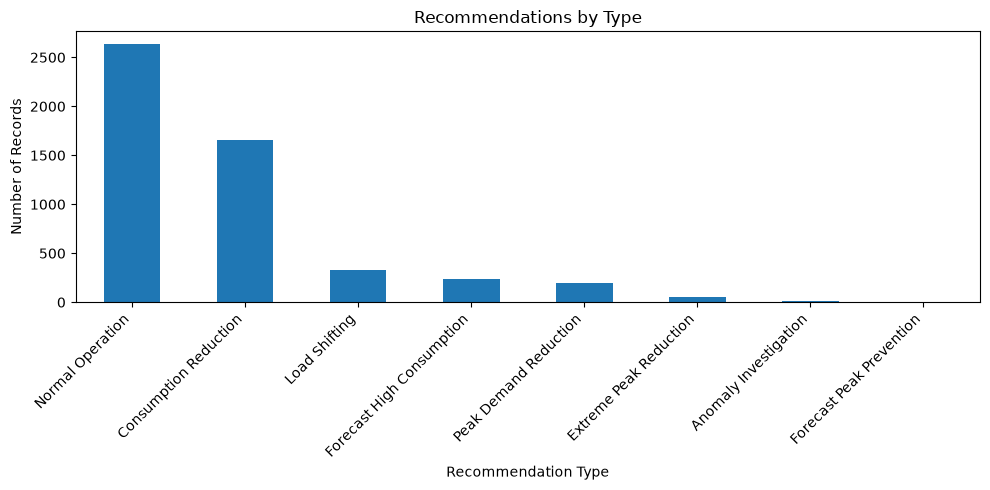

In [35]:
type_counts = (
    recommendation_df["recommendation_type"]
    .value_counts()
)

plt.figure(figsize=(10, 5))
type_counts.plot(kind="bar")

plt.title("Recommendations by Type")
plt.xlabel("Recommendation Type")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

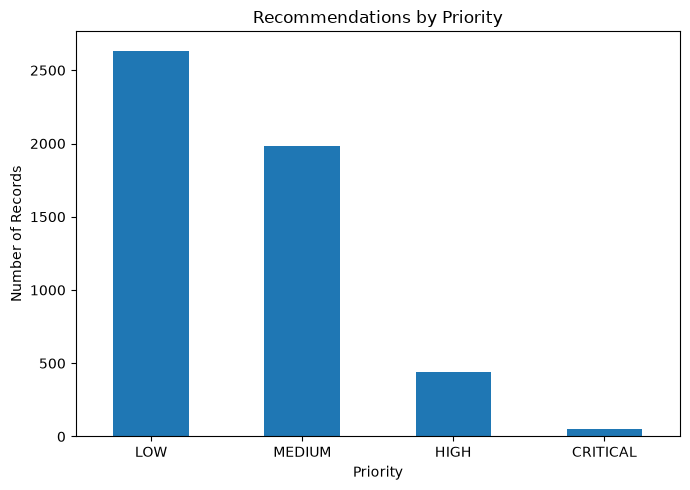

In [36]:
priority_counts = (
    recommendation_df["priority"]
    .value_counts()
)

plt.figure(figsize=(7, 5))
priority_counts.plot(kind="bar")

plt.title("Recommendations by Priority")
plt.xlabel("Priority")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

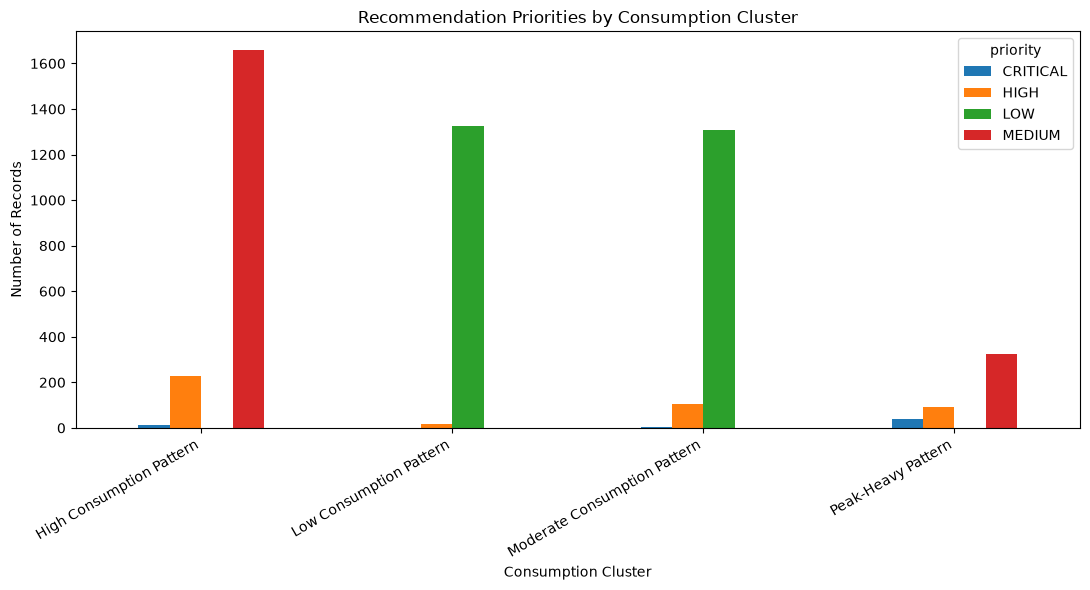

In [37]:
cluster_rec = pd.crosstab(
    recommendation_df["cluster_name"],
    recommendation_df["priority"]
)

cluster_rec.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Recommendation Priorities by Consumption Cluster")
plt.xlabel("Consumption Cluster")
plt.ylabel("Number of Records")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 6. Conclusion

The optimization and recommendation component successfully integrates
outputs from forecasting, deep-learning prediction, peak detection,
anomaly detection, and consumption clustering.

A data-driven high-consumption threshold was derived using the 90th
percentile of observed hourly consumption. Recommendations were generated
using a hierarchical rule-based approach so that more urgent conditions,
such as extreme peaks and anomalous high consumption, receive higher
priority than general consumption-pattern recommendations.

Each recommendation includes its supporting model signals, reason,
priority, and recommended optimization action.

Recommendation consistency was validated against the underlying model
outputs. All implemented validation checks passed for:

- Extreme peak reduction
- Anomaly investigation
- Peak-demand reduction
- Forecast peak prevention
- Forecast high-consumption reduction
- Peak-heavy load shifting
- High-consumption reduction

The final recommendation dataset is exported as `recommendations.csv`
for use by downstream components and energy-management decision support.